In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv("issizlik_tuik.csv")

In [2]:
df.head(10)

,Yıl,Ay,Nüfus,İş Gücü,İstihdam,İşsiz,İş Gücüne Dahil Değil,İşgücüne Katılım Oranı,İstihdam Oranı,İşsizlik Oranı
0,2005,Ocak,11515,4044,3245,798,7472,35.1,28.2,19.7
1,2005,Şubat,11513,3663,2976,687,7850,31.8,25.8,18.8
2,2005,Mart,11512,3812,3112,699,7700,33.1,27.0,18.3
3,2005,Nisan,11510,4132,3435,697,7378,35.9,29.8,16.9
4,2005,Mayıs,11509,4127,3479,648,7382,35.9,30.2,15.7
5,2005,Haziran,11507,4154,3490,664,7353,36.1,30.3,16.0
6,2005,Temmuz,11506,4469,3719,750,7037,38.8,32.3,16.8
7,2005,Ağustos,11504,4505,3808,697,6999,39.2,33.1,15.5
8,2005,Eylül,11503,4191,3505,686,7312,36.4,30.5,16.4
9,2005,Ekim,11501,4155,3471,685,7346,36.1,30.2,16.5


In [3]:
ay_sira = ["Ocak","Şubat","Mart","Nisan","Mayıs","Haziran",
           "Temmuz","Ağustos","Eylül","Ekim","Kasım","Aralık"]

df["Ay"] = pd.Categorical(df["Ay"], categories=ay_sira, ordered=True)
df = df.sort_values(["Yıl","Ay"]).reset_index(drop=True)

df["Ay_No"] = df["Ay"].cat.codes + 1
df["Tarih"] = pd.to_datetime(dict(year=df["Yıl"], month=df["Ay_No"], day=1))

print("Eksik değer sayıları:\n", df.isna().sum())

df.head() #boş veya null değer yok

Eksik değer sayıları:
 Yıl                       0
Ay                        0
Nüfus                     0
İş Gücü                   0
İstihdam                  0
İşsiz                     0
İş Gücüne Dahil Değil     0
İşgücüne Katılım Oranı    0
İstihdam Oranı            0
İşsizlik Oranı            0
Ay_No                     0
Tarih                     0
dtype: int64


,Yıl,Ay,Nüfus,İş Gücü,İstihdam,İşsiz,İş Gücüne Dahil Değil,İşgücüne Katılım Oranı,İstihdam Oranı,İşsizlik Oranı,Ay_No,Tarih
0,2005,Ocak,11515,4044,3245,798,7472,35.1,28.2,19.7,1,2005-01-01
1,2005,Şubat,11513,3663,2976,687,7850,31.8,25.8,18.8,2,2005-02-01
2,2005,Mart,11512,3812,3112,699,7700,33.1,27.0,18.3,3,2005-03-01
3,2005,Nisan,11510,4132,3435,697,7378,35.9,29.8,16.9,4,2005-04-01
4,2005,Mayıs,11509,4127,3479,648,7382,35.9,30.2,15.7,5,2005-05-01


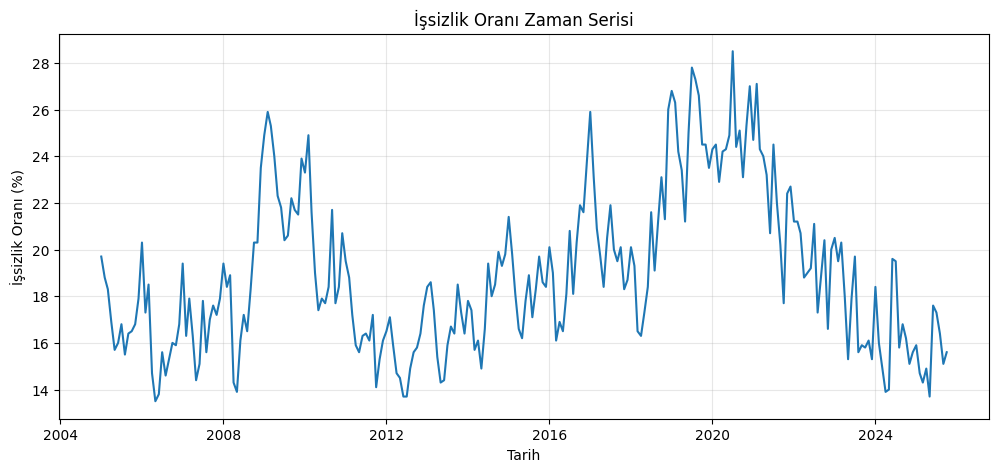

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df["Tarih"], df["İşsizlik Oranı"])
plt.title("İşsizlik Oranı Zaman Serisi")
plt.xlabel("Tarih")
plt.ylabel("İşsizlik Oranı (%)")
plt.grid(True, alpha=0.3)
plt.show()

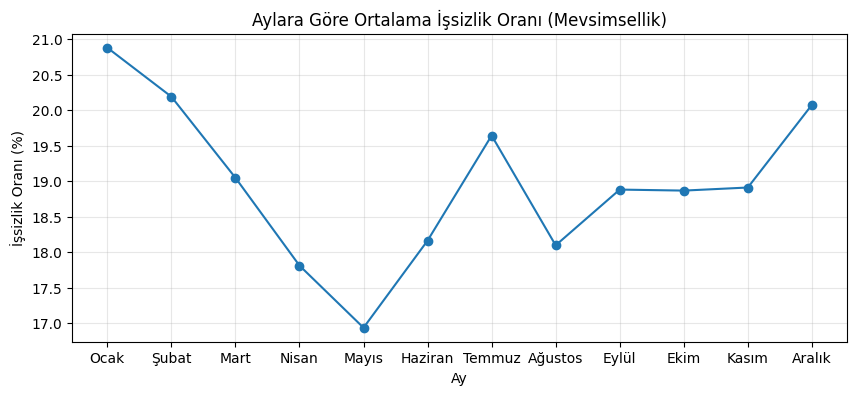

In [ ]:
ay_ort = df.groupby("Ay", observed=True)["İşsizlik Oranı"].mean()

plt.figure(figsize=(10,4))
plt.plot(ay_ort.index, ay_ort.values, marker="o")
plt.title("Aylara Göre Ortalama İşsizlik Oranı")
plt.xlabel("Ay")
plt.ylabel("İşsizlik Oranı (%)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
df2 = df.copy()

df2["lag_1"]  = df2["İşsizlik Oranı"].shift(1)
df2["lag_2"]  = df2["İşsizlik Oranı"].shift(2)
df2["lag_12"] = df2["İşsizlik Oranı"].shift(12)  # 1 yıl önce aynı ay

df2 = df2.dropna().reset_index(drop=True)
df2.head()


,Yıl,Ay,Nüfus,İş Gücü,İstihdam,İşsiz,İş Gücüne Dahil Değil,İşgücüne Katılım Oranı,İstihdam Oranı,İşsizlik Oranı,Ay_No,Tarih,lag_1,lag_2,lag_12
0,2006,Ocak,11496,3996,3183,813,7500,34.8,27.7,20.3,1,2006-01-01,17.9,16.8,19.7
1,2006,Şubat,11493,3713,3070,643,7780,32.3,26.7,17.3,2,2006-02-01,20.3,17.9,18.8
2,2006,Mart,11490,3803,3100,703,7687,33.1,27.0,18.5,3,2006-03-01,17.3,20.3,18.3
3,2006,Nisan,11487,4101,3498,604,7386,35.7,30.4,14.7,4,2006-04-01,18.5,17.3,16.9
4,2006,Mayıs,11484,3946,3412,534,7539,34.4,29.7,13.5,5,2006-05-01,14.7,18.5,15.7


In [ ]:
X = df2[["lag_1","lag_2","lag_12"]]
y = df2["İşsizlik Oranı"]

split = int(len(df2)*0.85)  # son %15 test
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]
t_test = df2["Tarih"].iloc[split:]

In [ ]:
def report(y_true, y_pred, name="Model"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name} -> RMSE: {rmse:.3f} | R²: {r2:.3f}")
    return rmse, r2

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

report(y_test, pred_lr, "LinearRegression")

LinearRegression -> RMSE: 1.865 | R²: 0.073


(np.float64(1.8653167036321474), 0.07262198104971473)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=500,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

report(y_test, pred_rf, "RandomForestRegressor")


RandomForestRegressor -> RMSE: 1.955 | R²: -0.019


(np.float64(1.9550929193604334), -0.018794155810975433)

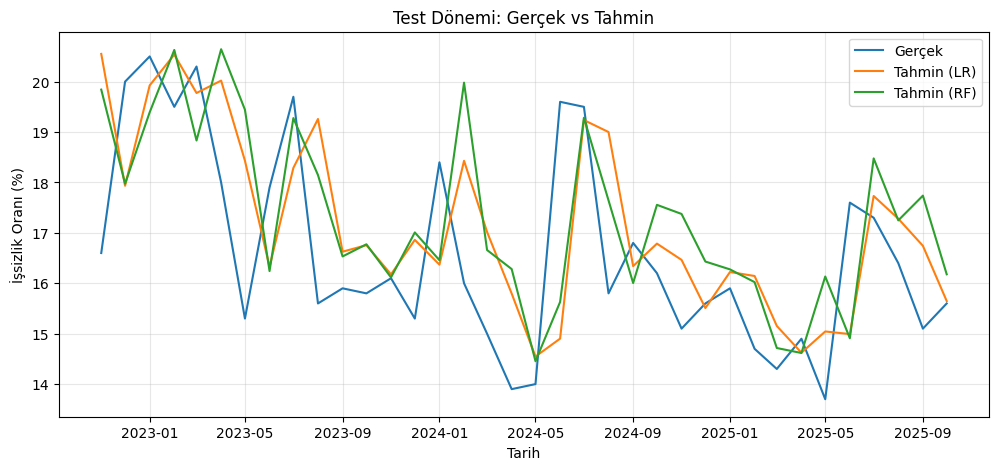

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(t_test, y_test.values, label="Gerçek")
plt.plot(t_test, pred_lr, label="Tahmin (LR)")
plt.plot(t_test, pred_rf, label="Tahmin (RF)")
plt.title("Test Dönemi: Gerçek vs Tahmin")
plt.xlabel("Tarih")
plt.ylabel("İşsizlik Oranı (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [ ]:
best_model = rf #tahminimize random forest ile devam ediyoruz.

best_model.fit(X, y)

history = df["İşsizlik Oranı"].tolist()

future_dates = pd.date_range("2026-01-01", "2026-12-01", freq="MS")
future_preds = []

for i in range(12):
    lag_1  = history[-1]
    lag_2  = history[-2]
    lag_12 = history[-12]
    x_new = np.array([[lag_1, lag_2, lag_12]])
    y_hat = float(best_model.predict(x_new)[0])

    future_preds.append(y_hat)
    history.append(y_hat)

tahmin_2026 = pd.DataFrame({
    "Tarih": future_dates,
    "Yıl": future_dates.year,
    "Ay": [ay_sira[m-1] for m in future_dates.month],
    "Tahmini İşsizlik Oranı": future_preds
})

tahmin_2026

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/

,Tarih,Yıl,Ay,Tahmini İşsizlik Oranı
0,2026-01-01,2026,Ocak,16.0646
1,2026-02-01,2026,Şubat,15.8592
2,2026-03-01,2026,Mart,15.3728
3,2026-04-01,2026,Nisan,15.4160
4,2026-05-01,2026,Mayıs,15.3806
5,2026-06-01,2026,Haziran,15.7298
6,2026-07-01,2026,Temmuz,15.3622
7,2026-08-01,2026,Ağustos,16.2358
8,2026-09-01,2026,Eylül,16.4442
9,2026-10-01,2026,Ekim,17.0148


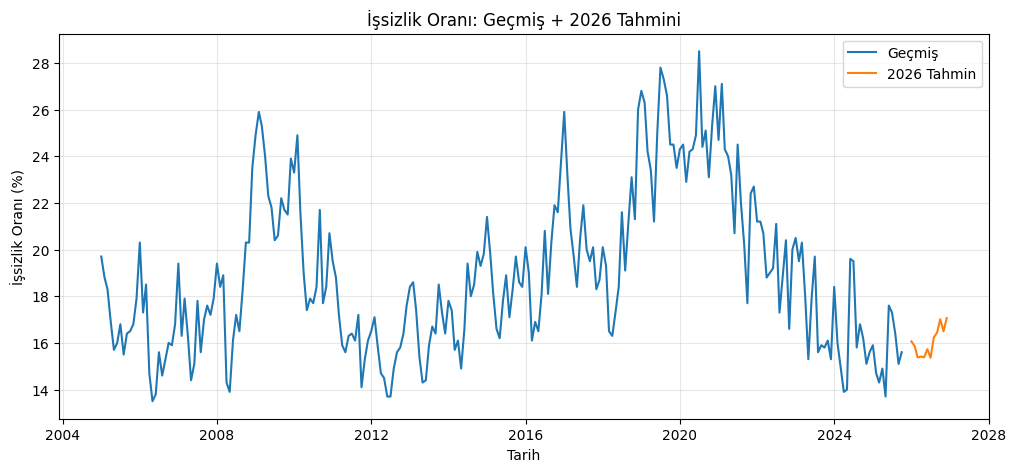

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df["Tarih"], df["İşsizlik Oranı"], label="Geçmiş")
plt.plot(tahmin_2026["Tarih"], tahmin_2026["Tahmini İşsizlik Oranı"], label="2026 Tahmin")
plt.title("İşsizlik Oranı: Geçmiş + 2026 Tahmini")
plt.xlabel("Tarih")
plt.ylabel("İşsizlik Oranı (%)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()